In [32]:
import pandas as pd
import os
import glob
import time

# Define the results directory where the parquet files are stored
results_dir = "/home/jake/Document/Spikes/projects/mnist_class/mnist_class_wip/results/trials/"
weight_version = "epoch_0_item_0"  # Change this to match your weight version
noise_version = "noise_5"
split = "train"
# Path pattern to find all the parquet files
file_pattern = os.path.join(results_dir, weight_version,noise_version,split, "neuron_input_batch_*", "metrics.parquet")
print(file_pattern)
# Get list of all parquet files
parquet_files = glob.glob(file_pattern)
print(f"Found {len(parquet_files)} parquet files")

def load_all_parquet_files_with_global_stimulus_id():
    start_time = time.time()
    print("Loading all parquet files with global stimulus IDs...")
    
    dfs = []
    global_stimulus_offset = 0
    
    for i, file in enumerate(parquet_files):
        if i % 10 == 0:
            print(f"Loading file {i}/{len(parquet_files)}")
        
        df_batch = pd.read_parquet(file)
        
        # Add global offset to stimulus_id to make them unique
        df_batch['stimulus_id'] = df_batch['stimulus_id'] + global_stimulus_offset
        
        # Update offset for next batch (assume max 50 stimuli per batch)
        max_stimulus_in_batch = df_batch['stimulus_id'].max() - global_stimulus_offset + 1
        global_stimulus_offset += max_stimulus_in_batch
        
        dfs.append(df_batch)
        
        if i == 0:  # Debug first batch
            print(f"First batch stimulus_id range: {df_batch['stimulus_id'].min()} to {df_batch['stimulus_id'].max()}")
    
    # Concatenate all DataFrames
    full_df = pd.concat(dfs, ignore_index=True)
    
    print(f"Loaded {len(full_df)} rows in {time.time() - start_time:.2f} seconds")
    print(f"Global stimulus_id range: {full_df['stimulus_id'].min()} to {full_df['stimulus_id'].max()}")
    print(f"Total unique stimuli: {full_df['stimulus_id'].nunique()}")
    
    return full_df

# Use the corrected loading function
df = load_all_parquet_files_with_global_stimulus_id()

/home/jake/Document/Spikes/projects/mnist_class/mnist_class_wip/results/trials/epoch_0_item_0/noise_5/train/neuron_input_batch_*/metrics.parquet
Found 765 parquet files
Loading all parquet files with global stimulus IDs...
Loading file 0/765
First batch stimulus_id range: 0 to 49
Loading file 10/765
Loading file 20/765
Loading file 30/765
Loading file 40/765
Loading file 50/765
Loading file 60/765
Loading file 70/765
Loading file 80/765
Loading file 90/765
Loading file 100/765
Loading file 110/765
Loading file 120/765
Loading file 130/765
Loading file 140/765
Loading file 150/765
Loading file 160/765
Loading file 170/765
Loading file 180/765
Loading file 190/765
Loading file 200/765
Loading file 210/765
Loading file 220/765
Loading file 230/765
Loading file 240/765
Loading file 250/765
Loading file 260/765
Loading file 270/765
Loading file 280/765
Loading file 290/765
Loading file 300/765
Loading file 310/765
Loading file 320/765
Loading file 330/765
Loading file 340/765
Loading file 3

What's the plan here?
Want to spin up a csv 
    Different columns (noise) vs. (epochs)
    Then basically I'll make a queue for items to sort...




    

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

print("Preparing data - each neuron becomes a feature")

def prepare_neural_features(df, max_stimuli=20000):
    """
    Convert from long format to wide format:
    - Each stimulus becomes one row
    - Each neuron becomes 2 columns (latency + count) 
    - Result: 8192 features per stimulus (4096 latency + 4096 count)
    """
    
    print(f"Input data shape: {df.shape}")
    print(f"Unique stimuli: {df['stimulus_id'].nunique()}")
    
    # Limit to first N stimuli for comparability
    if max_stimuli is not None:
        unique_stimuli = sorted(df['stimulus_id'].unique())
        selected_stimuli = unique_stimuli[:max_stimuli]
        df_filtered = df[df['stimulus_id'].isin(selected_stimuli)]
        print(f"Filtered to first {len(selected_stimuli)} stimuli")
        print(f"Filtered data shape: {df_filtered.shape}")
    else:
        df_filtered = df
    
    print(f"Unique neurons: {df_filtered['neuron_id'].nunique()}")
    print(f"Expected neurons per stimulus: {df_filtered['neuron_id'].nunique()}")
    
    # Check if we have complete data
    stimuli_per_neuron = df_filtered.groupby('stimulus_id').size().unique()
    print(f"Neurons per stimulus: {stimuli_per_neuron}")
    
    # Pivot latency data: rows=stimulus_id, columns=neuron_id, values=latency
    print("Creating latency feature matrix...")
    latency_pivot = df_filtered.pivot(index='stimulus_id', columns='neuron_id', values='latency')
    
    # Pivot count data: rows=stimulus_id, columns=neuron_id, values=count  
    print("Creating count feature matrix...")
    count_pivot = df_filtered.pivot(index='stimulus_id', columns='neuron_id', values='count')
    
    # Get labels (one per stimulus)
    labels = df_filtered.groupby('stimulus_id')['label'].first()
    
    # Combine latency and count features
    print("Combining features...")
    # Add prefixes to distinguish latency vs count features
    latency_pivot.columns = [f'latency_n{col}' for col in latency_pivot.columns]
    count_pivot.columns = [f'count_n{col}' for col in count_pivot.columns]
    
    # Concatenate horizontally
    all_features = pd.concat([latency_pivot, count_pivot], axis=1)
    
    print(f"Feature matrix shape: {all_features.shape}")
    print(f"Expected shape: ({len(labels)}, 8192)")
    
    # Convert to numpy
    X = all_features.values
    y = labels.values
    
    # Handle any missing values
    if np.isnan(X).any():
        print("Warning: Found NaN values, filling with 0")
        X = np.nan_to_num(X, nan=0.0)
    
    print(f"Final X shape: {X.shape}")
    print(f"Final y shape: {y.shape}")
    
    # Show class distribution for the subset
    unique_classes, counts = np.unique(y, return_counts=True)
    print(f"\nClass distribution in subset:")
    for cls, count in zip(unique_classes, counts):
        print(f"Class {cls}: {count} samples ({count/len(y)*100:.1f}%)")
    
    return X, y

# Prepare the data with only first 400 stimuli
X, y = prepare_neural_features(df, max_stimuli=400)

# Prepare the data
X, y = prepare_neural_features(df)

# Scale features (important for neural network)
print("Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature statistics after scaling:")
print(f"Mean: {X_scaled.mean():.4f}")
print(f"Std: {X_scaled.std():.4f}")

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.LongTensor(y)

print(f"Class distribution:")
unique_classes, counts = np.unique(y, return_counts=True)
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} samples ({count/len(y)*100:.1f}%)")

Preparing data - each neuron becomes a feature
Input data shape: (156672000, 5)
Unique stimuli: 38250
Filtered to first 400 stimuli
Filtered data shape: (1638400, 5)
Unique neurons: 4096
Expected neurons per stimulus: 4096
Neurons per stimulus: [4096]
Creating latency feature matrix...
Creating count feature matrix...
Combining features...
Feature matrix shape: (400, 8192)
Expected shape: (400, 8192)
Final X shape: (400, 8192)
Final y shape: (400,)

Class distribution in subset:
Class 0: 35 samples (8.8%)
Class 1: 38 samples (9.5%)
Class 2: 35 samples (8.8%)
Class 3: 43 samples (10.8%)
Class 4: 42 samples (10.5%)
Class 5: 40 samples (10.0%)
Class 6: 41 samples (10.2%)
Class 7: 41 samples (10.2%)
Class 8: 36 samples (9.0%)
Class 9: 49 samples (12.2%)
Input data shape: (156672000, 5)
Unique stimuli: 38250
Filtered to first 20000 stimuli
Filtered data shape: (81920000, 5)
Unique neurons: 4096
Expected neurons per stimulus: 4096
Neurons per stimulus: [4096]
Creating latency feature matrix.

Splitting data...


Train size: 16000, Test size: 4000
Using device: cuda
Model input size: 8192
Number of classes: 10
Model parameters: 81,930
Starting training...
Epoch  20: Loss=0.2185, Train Acc=0.9385, Test Acc=0.7728
Epoch  40: Loss=0.1412, Train Acc=0.9573, Test Acc=0.7730
Epoch  60: Loss=0.1104, Train Acc=0.9663, Test Acc=0.7430
Epoch  80: Loss=0.1151, Train Acc=0.9644, Test Acc=0.7615
Epoch 100: Loss=0.0958, Train Acc=0.9731, Test Acc=0.7540

FINAL RESULTS
Best Test Accuracy: 0.7857 (78.6%)
Final Test Accuracy: 0.7540 (75.4%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.73      0.85      0.78       397
     Digit 1       0.86      0.90      0.88       455
     Digit 2       0.82      0.71      0.76       406
     Digit 3       0.74      0.74      0.74       414
     Digit 4       0.72      0.62      0.67       378
     Digit 5       0.72      0.73      0.73       362
     Digit 6       0.83      0.82      0.82       385
     Digit 7 

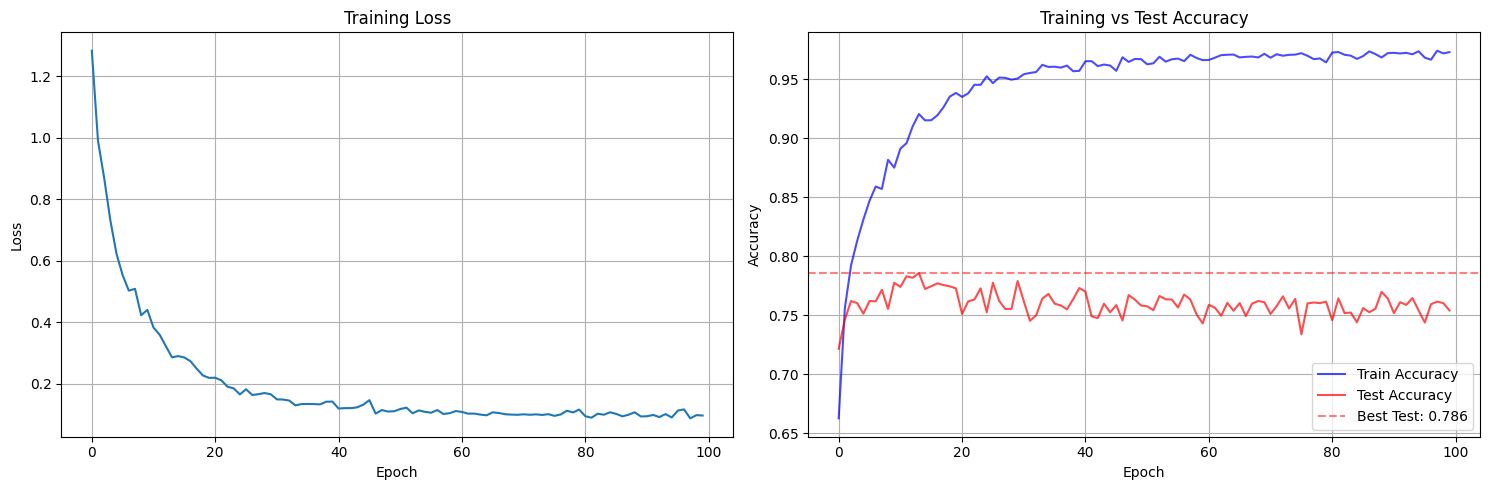

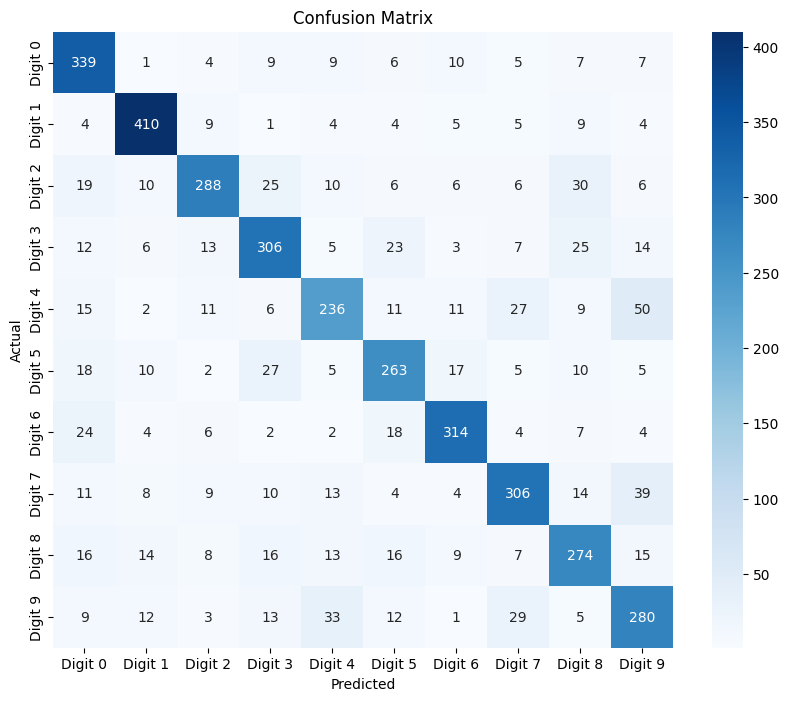


📊 Training Summary:
📈 Best Test Accuracy: 78.6%
📉 Final Training Loss: 0.0958
🎯 Total Parameters: 81,930
📋 Test Samples: 4000
⚠️  Possible overfitting detected!

Top 10 most important features:
 1. latency_neuron_37: 0.2162
 2. count_neuron_1445: 0.1795
 3. count_neuron_743: 0.1792
 4. latency_neuron_320: 0.1720
 5. count_neuron_3081: 0.1655
 6. latency_neuron_4033: 0.1616
 7. count_neuron_3513: 0.1593
 8. count_neuron_3131: 0.1558
 9. latency_neuron_4095: 0.1541
10. count_neuron_953: 0.1515


In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression Model
class LogisticRegressionNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
        
    def forward(self, x):
        return self.linear(x)  # No softmax - CrossEntropyLoss includes it

# Split the data
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Create data loaders
batch_size = 128
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

num_features = X_tensor.shape[1]
num_classes = len(unique_classes)

model = LogisticRegressionNet(num_features, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Model input size: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training function
def train_and_evaluate(epochs=100):
    train_losses = []
    train_accs = []
    test_accs = []
    
    best_test_acc = 0.0
    best_model_state = None
    
    print("Starting training...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss = 0
        correct_train = 0
        total_train = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()
        
        # Evaluation phase
        model.eval()
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                total_test += batch_y.size(0)
                correct_test += (predicted == batch_y).sum().item()
        
        # Calculate metrics
        avg_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train
        test_acc = correct_test / total_test
        
        train_losses.append(avg_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # Save best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = model.state_dict().copy()
        
        # Print progress
        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:3d}: Loss={avg_loss:.4f}, '
                  f'Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}')
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return train_losses, train_accs, test_accs, best_test_acc

# Train the model
train_losses, train_accs, test_accs, best_test_acc = train_and_evaluate(epochs=100)

# Final evaluation
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Best Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.1f}%)")
print(f"Final Test Accuracy: {test_accs[-1]:.4f} ({test_accs[-1]*100:.1f}%)")

# Detailed predictions
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_predictions, 
                          target_names=[f'Digit {i}' for i in unique_classes]))

# Per-class accuracy
print(f"\nPer-class accuracy:")
for digit in unique_classes:
    mask = np.array(all_labels) == digit
    if mask.sum() > 0:
        class_acc = accuracy_score(np.array(all_labels)[mask], 
                                 np.array(all_predictions)[mask])
        print(f"Digit {digit}: {class_acc:.4f} ({class_acc*100:.1f}%)")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Accuracy', color='blue', alpha=0.7)
ax2.plot(test_accs, label='Test Accuracy', color='red', alpha=0.7)
ax2.axhline(y=best_test_acc, color='red', linestyle='--', alpha=0.5, 
           label=f'Best Test: {best_test_acc:.3f}')
ax2.set_title('Training vs Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=[f'Digit {i}' for i in unique_classes],
           yticklabels=[f'Digit {i}' for i in unique_classes])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Check for overfitting
print(f"\n📊 Training Summary:")
print(f"📈 Best Test Accuracy: {best_test_acc:.1%}")
print(f"📉 Final Training Loss: {train_losses[-1]:.4f}")
print(f"🎯 Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"📋 Test Samples: {len(all_labels)}")

if train_accs[-1] - test_accs[-1] > 0.1:
    print("⚠️  Possible overfitting detected!")
else:
    print("✅ Good generalization!")

# Feature importance (weights magnitude)
model.eval()
weights = model.linear.weight.detach().cpu().numpy()
feature_importance = np.mean(np.abs(weights), axis=0)

print(f"\nTop 10 most important features:")
top_features = np.argsort(feature_importance)[-10:][::-1]
for i, feat_idx in enumerate(top_features):
    importance = feature_importance[feat_idx]
    if feat_idx < 4096:
        feat_name = f"latency_neuron_{feat_idx}"
    else:
        feat_name = f"count_neuron_{feat_idx-4096}"
    print(f"{i+1:2d}. {feat_name}: {importance:.4f}")

In [20]:
class EnhancedRegularizedNet(nn.Module):
    def __init__(self, input_size, num_classes, dropout_rate=0.3, use_batch_norm=True):
        super().__init__()
        
        layers = []
        
        # Input dropout
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        # Main linear layer
        layers.append(nn.Linear(input_size, num_classes))
        
        # Optional batch normalization
        if use_batch_norm:
            layers.append(nn.BatchNorm1d(num_classes))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Test the enhanced model with best parameters
def train_with_best_params(best_params):
    """Train final model with best regularization parameters"""
    
    model = EnhancedRegularizedNet(
        num_features, 
        num_classes, 
        dropout_rate=best_params['dropout'],
        use_batch_norm=True
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=best_params['learning_rate'], 
        weight_decay=best_params['weight_decay']
    )
    
    # Train with the optimized parameters
    train_losses, train_accs, test_accs, best_test_acc = train_and_evaluate_enhanced(
        model, criterion, optimizer, epochs=100
    )
    
    return model, train_losses, train_accs, test_accs, best_test_acc

def train_and_evaluate_enhanced(model, criterion, optimizer, epochs=100):
    """Enhanced training with early stopping"""
    train_losses = []
    train_accs = []
    test_accs = []
    
    best_test_acc = 0.0
    best_model_state = None
    patience = 20
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss = 0
        correct_train = 0
        total_train = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping (another form of regularization)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()
        
        # Evaluation phase
        model.eval()
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                total_test += batch_y.size(0)
                correct_test += (predicted == batch_y).sum().item()
        
        # Calculate metrics
        avg_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train
        test_acc = correct_test / total_test
        
        train_losses.append(avg_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # Early stopping logic
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        # Print progress
        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:3d}: Loss={avg_loss:.4f}, '
                  f'Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}')
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return train_losses, train_accs, test_accs, best_test_acc

# Run the enhanced training
print("Training with optimized regularization...")
optimized_model, opt_losses, opt_train_accs, opt_test_accs, opt_best_acc = train_with_best_params(best_params)

print(f"\nOptimized model performance: {opt_best_acc:.4f}")

Training with optimized regularization...


Epoch  20: Loss=0.5652, Train Acc=0.9424, Test Acc=0.8276
Early stopping at epoch 36

Optimized model performance: 0.8409


In [19]:
from itertools import product
import pandas as pd

def grid_search_regularization():
    """Grid search over different regularization parameters"""
    
    # Define parameter grid
    learning_rates = [0.01, 0.001, 0.0001]
    weight_decays = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
    dropout_rates = [0.0, 0.1, 0.3, 0.5]
    
    results = []
    
    print("Starting regularization grid search...")
    print(f"Total combinations: {len(learning_rates) * len(weight_decays) * len(dropout_rates)}")
    
    for i, (lr, wd, dropout) in enumerate(product(learning_rates, weight_decays, dropout_rates)):
        print(f"\nTesting combination {i+1}: lr={lr}, weight_decay={wd}, dropout={dropout}")
        
        # Create model with dropout
        class RegularizedNet(nn.Module):
            def __init__(self, input_size, num_classes, dropout_rate):
                super().__init__()
                self.dropout = nn.Dropout(dropout_rate)
                self.linear = nn.Linear(input_size, num_classes)
                
            def forward(self, x):
                x = self.dropout(x)  # Apply dropout to input features
                return self.linear(x)
        
        # Train model with these parameters
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = RegularizedNet(num_features, num_classes, dropout).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        
        # Quick training (fewer epochs for grid search)
        best_acc = train_quick(model, criterion, optimizer, train_loader, test_loader, epochs=30)
        
        results.append({
            'learning_rate': lr,
            'weight_decay': wd,
            'dropout': dropout,
            'best_accuracy': best_acc
        })
        
        print(f"Best accuracy: {best_acc:.4f}")
    
    # Convert to DataFrame and find best
    results_df = pd.DataFrame(results)
    best_params = results_df.loc[results_df['best_accuracy'].idxmax()]
    
    print("\n" + "="*60)
    print("GRID SEARCH RESULTS")
    print("="*60)
    print(f"Best parameters:")
    print(f"Learning Rate: {best_params['learning_rate']}")
    print(f"Weight Decay: {best_params['weight_decay']}")
    print(f"Dropout: {best_params['dropout']}")
    print(f"Best Accuracy: {best_params['best_accuracy']:.4f}")
    
    return results_df, best_params

def train_quick(model, criterion, optimizer, train_loader, test_loader, epochs=30):
    """Quick training for grid search"""
    best_acc = 0.0
    
    for epoch in range(epochs):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        # Evaluation every 10 epochs
        if epoch % 10 == 0:
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    outputs = model(batch_X)
                    _, predicted = torch.max(outputs, 1)
                    total += batch_y.size(0)
                    correct += (predicted == batch_y).sum().item()
            
            acc = correct / total
            best_acc = max(best_acc, acc)
    
    return best_acc

# Run grid search
results_df, best_params = grid_search_regularization()

Starting regularization grid search...
Total combinations: 60

Testing combination 1: lr=0.01, weight_decay=0.0, dropout=0.0
Best accuracy: 0.7690

Testing combination 2: lr=0.01, weight_decay=0.0, dropout=0.1
Best accuracy: 0.7966

Testing combination 3: lr=0.01, weight_decay=0.0, dropout=0.3
Best accuracy: 0.8099

Testing combination 4: lr=0.01, weight_decay=0.0, dropout=0.5
Best accuracy: 0.8029

Testing combination 5: lr=0.01, weight_decay=1e-05, dropout=0.0
Best accuracy: 0.8126

Testing combination 6: lr=0.01, weight_decay=1e-05, dropout=0.1
Best accuracy: 0.7966

Testing combination 7: lr=0.01, weight_decay=1e-05, dropout=0.3
Best accuracy: 0.8242

Testing combination 8: lr=0.01, weight_decay=1e-05, dropout=0.5
Best accuracy: 0.8123

Testing combination 9: lr=0.01, weight_decay=0.0001, dropout=0.0
Best accuracy: 0.7973

Testing combination 10: lr=0.01, weight_decay=0.0001, dropout=0.1
Best accuracy: 0.7840

Testing combination 11: lr=0.01, weight_decay=0.0001, dropout=0.3
Best a